# 2 - Interval Analysis

## Imports

In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [7]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [8]:
metadata = g.load_metadata()

In [9]:
bins = np.arange(1930, 2030, 10) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

subset_year = metadata[metadata['recording_year'].notna()].copy()
subset_year['year_bin'] = pd.cut(subset_year['recording_year'], bins=bins, labels=bin_labels, right=False)

## In-Label Intervals

### Example: Subset

In [175]:


subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]


In [176]:
ILC = g.load_labels(subset)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
identifier = ['artist', 'workTitle']
ILC = ILC.groupby(identifier, as_index=False).agg(list)

In [177]:
data = ia.create_data(ILC, identifier)

In [178]:
#ia.plot_interval_distribution(data, identifier)

- Next step: notes sounding simultaneously (consider duration !!!)
- Debug: look at two pieces in same key and two pieces in different keys to look at the interval and pitch class
- group plots by artist or key or year 

### By artist

In [199]:
grouped_artists = metadata['artists'].value_counts()
subset_artists = grouped_artists.iloc[0:8].index
subset = metadata[metadata['artists'].isin(subset_artists)]
subset_artists

Index(['Frank Zappa', 'Bill Evans', 'Yohan Kim', 'Dexter Gordon',
       'Miles Davis', 'Chet Baker', 'Bob Mintzer', 'Paul Desmond'],
      dtype='object')

In [200]:
ILC = g.load_labels(subset)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
identifier = ['artist']
ILC = ILC.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(ILC, identifier)

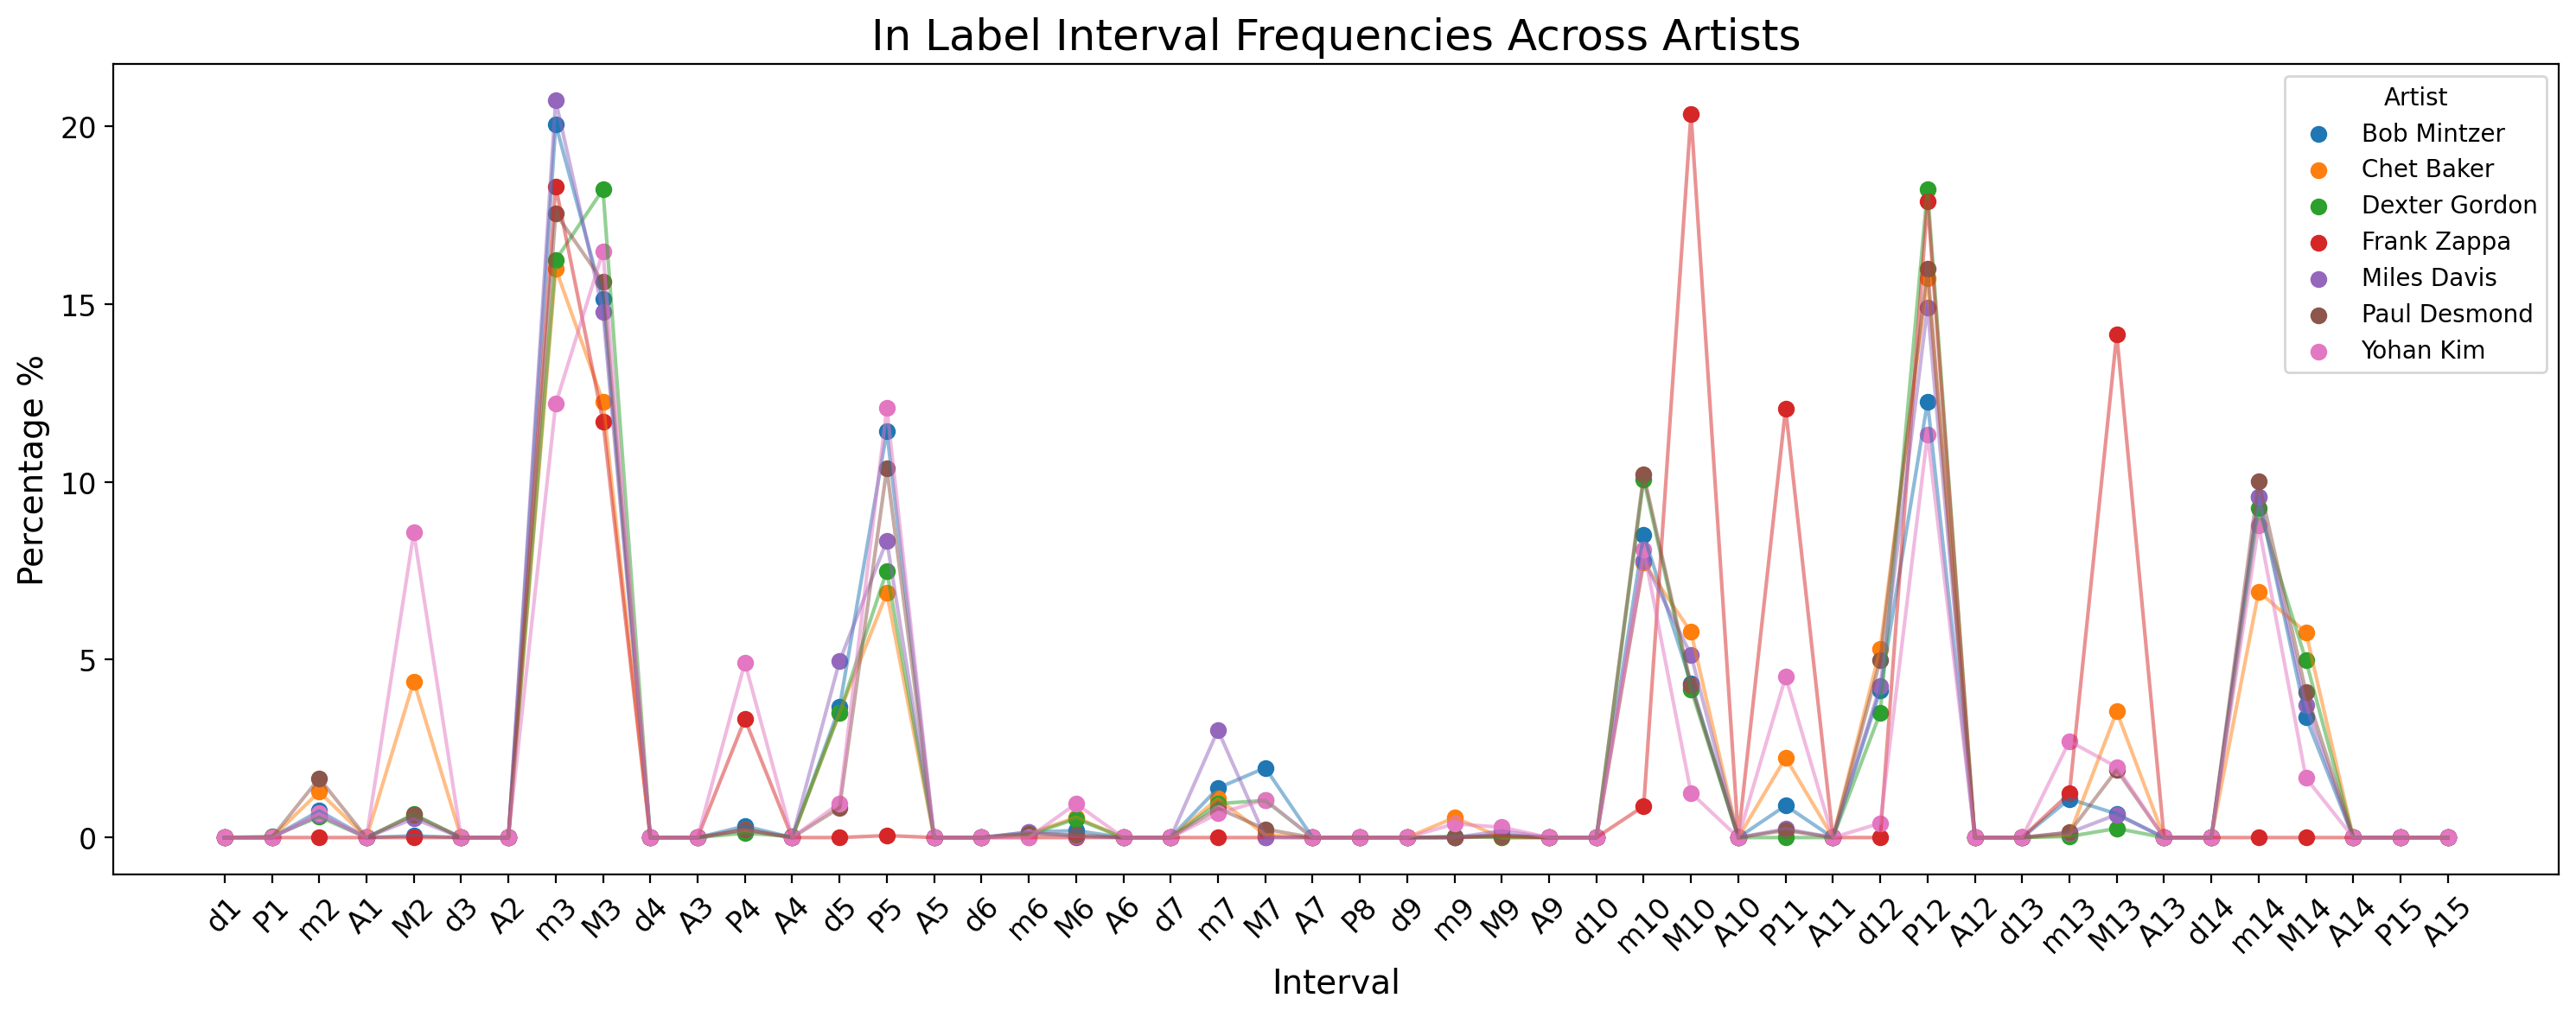

In [215]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['tab10']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i))
    
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)

ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In Label Interval Frequencies Across Artists', fontsize=18)
ax.legend(title='Artist')


plt.tight_layout()
plt.savefig(f"../Results/Artist_Interval_InLabel")
plt.show()

In [160]:
#ia.plot_interval_distribution(data, identifier)

### By year

In [70]:
ILC_year = g.load_labels(subset_year)
ILC_year['interval'] = ILC_year['label'].apply(lambda x: ia.label_to_intervals_semitones(x)[0])
ILC_year['interval from root'] = ILC_year['label'].apply(lambda x: ia.label_to_intervals_semitones_from_root(x)[0])
identifier = ['year_bin']
ILC_year_grouped = ILC_year.groupby(identifier, as_index=False).agg(list)
data_ILC_year = ia.create_data(ILC_year_grouped, identifier)


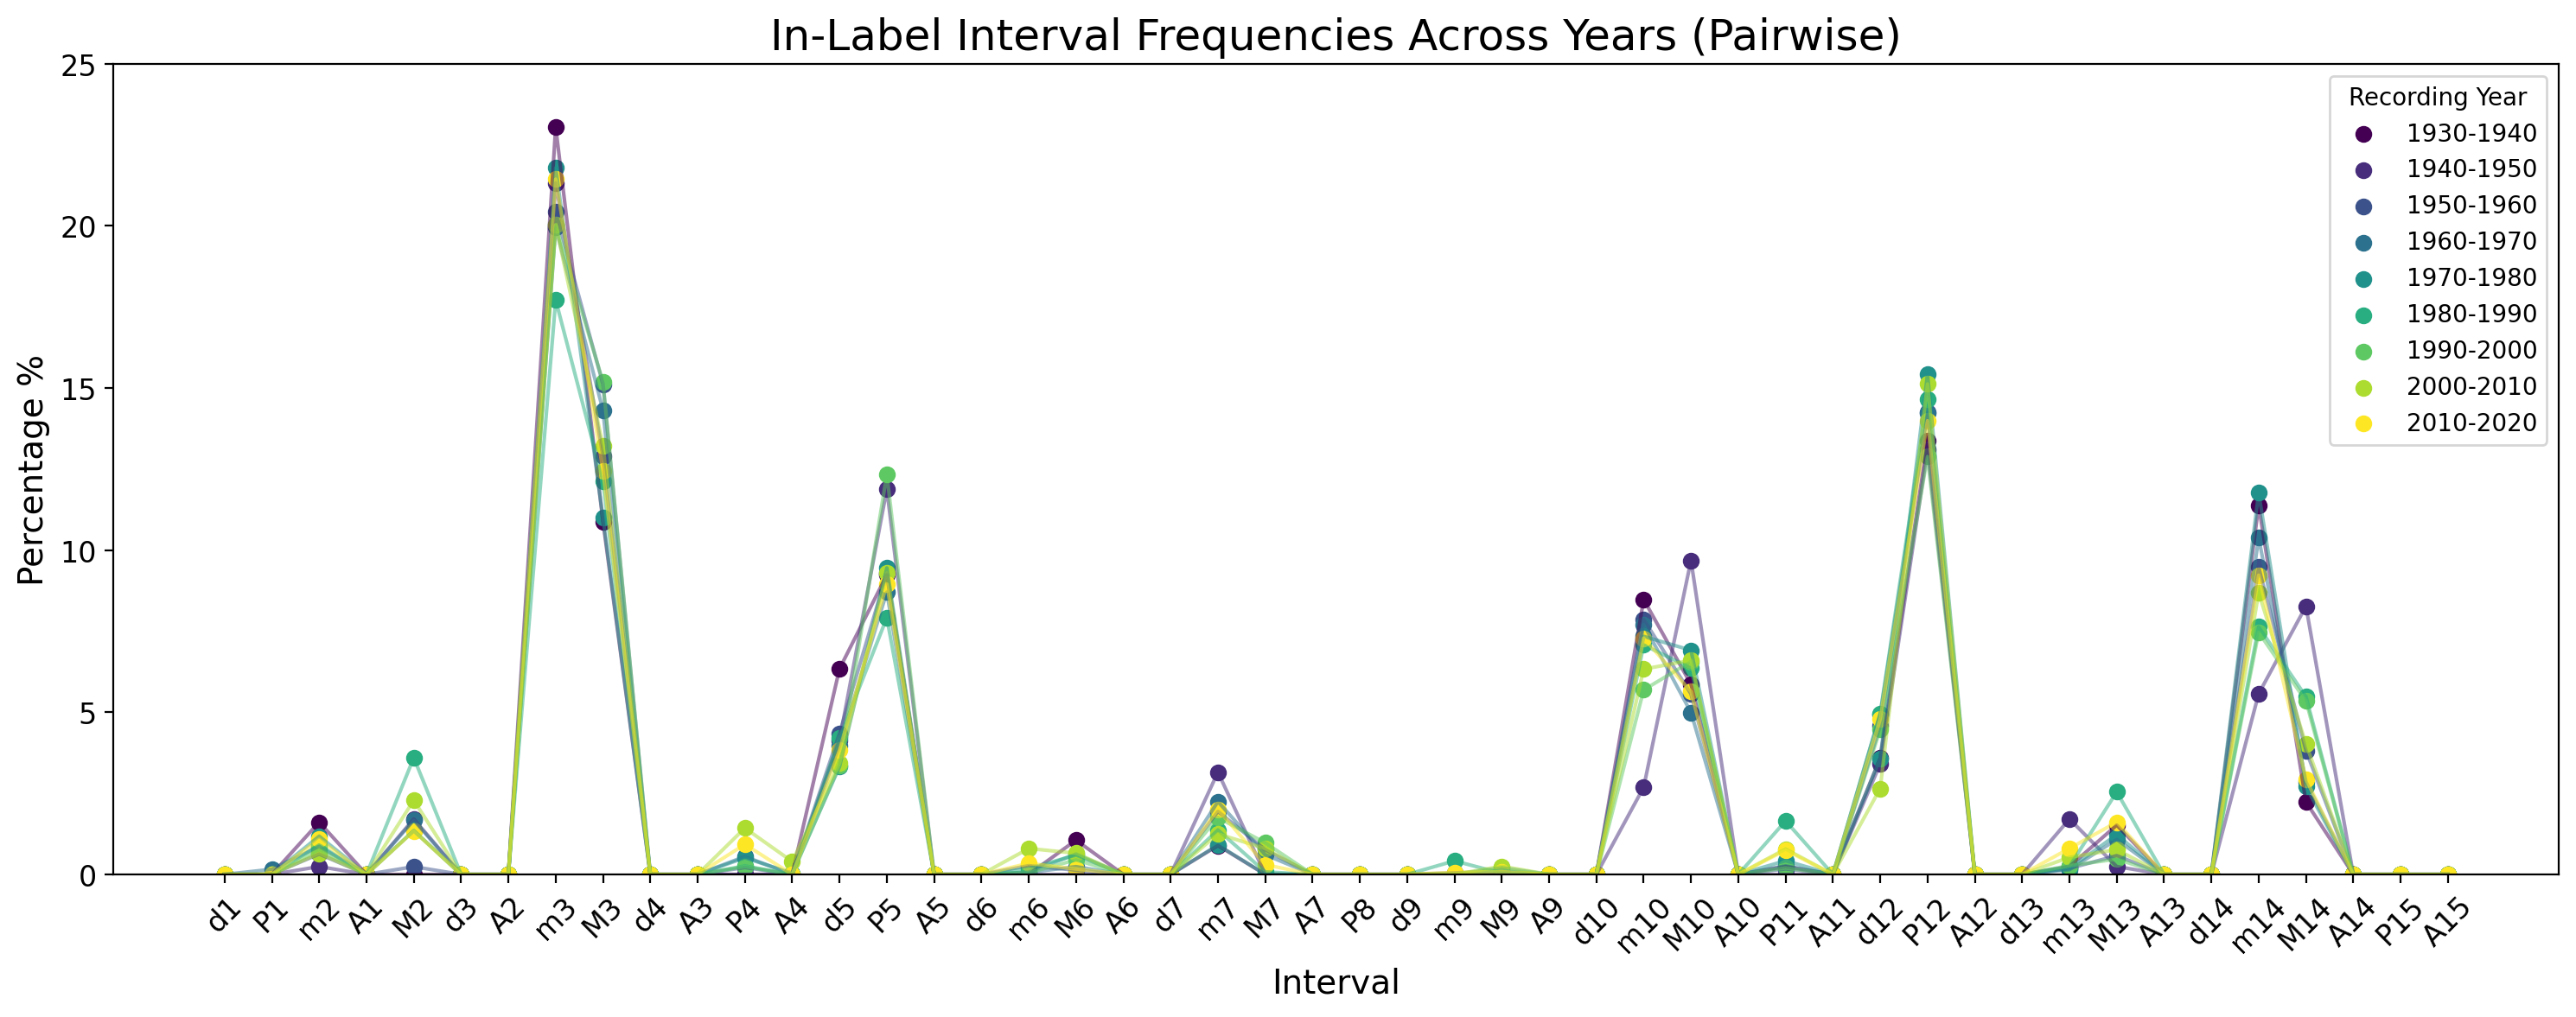

In [72]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_ILC_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data_ILC_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In-Label Interval Frequencies Across Years (Pairwise)', fontsize=18)
ax.legend(title='Recording Year')
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_InLabel")
plt.show()

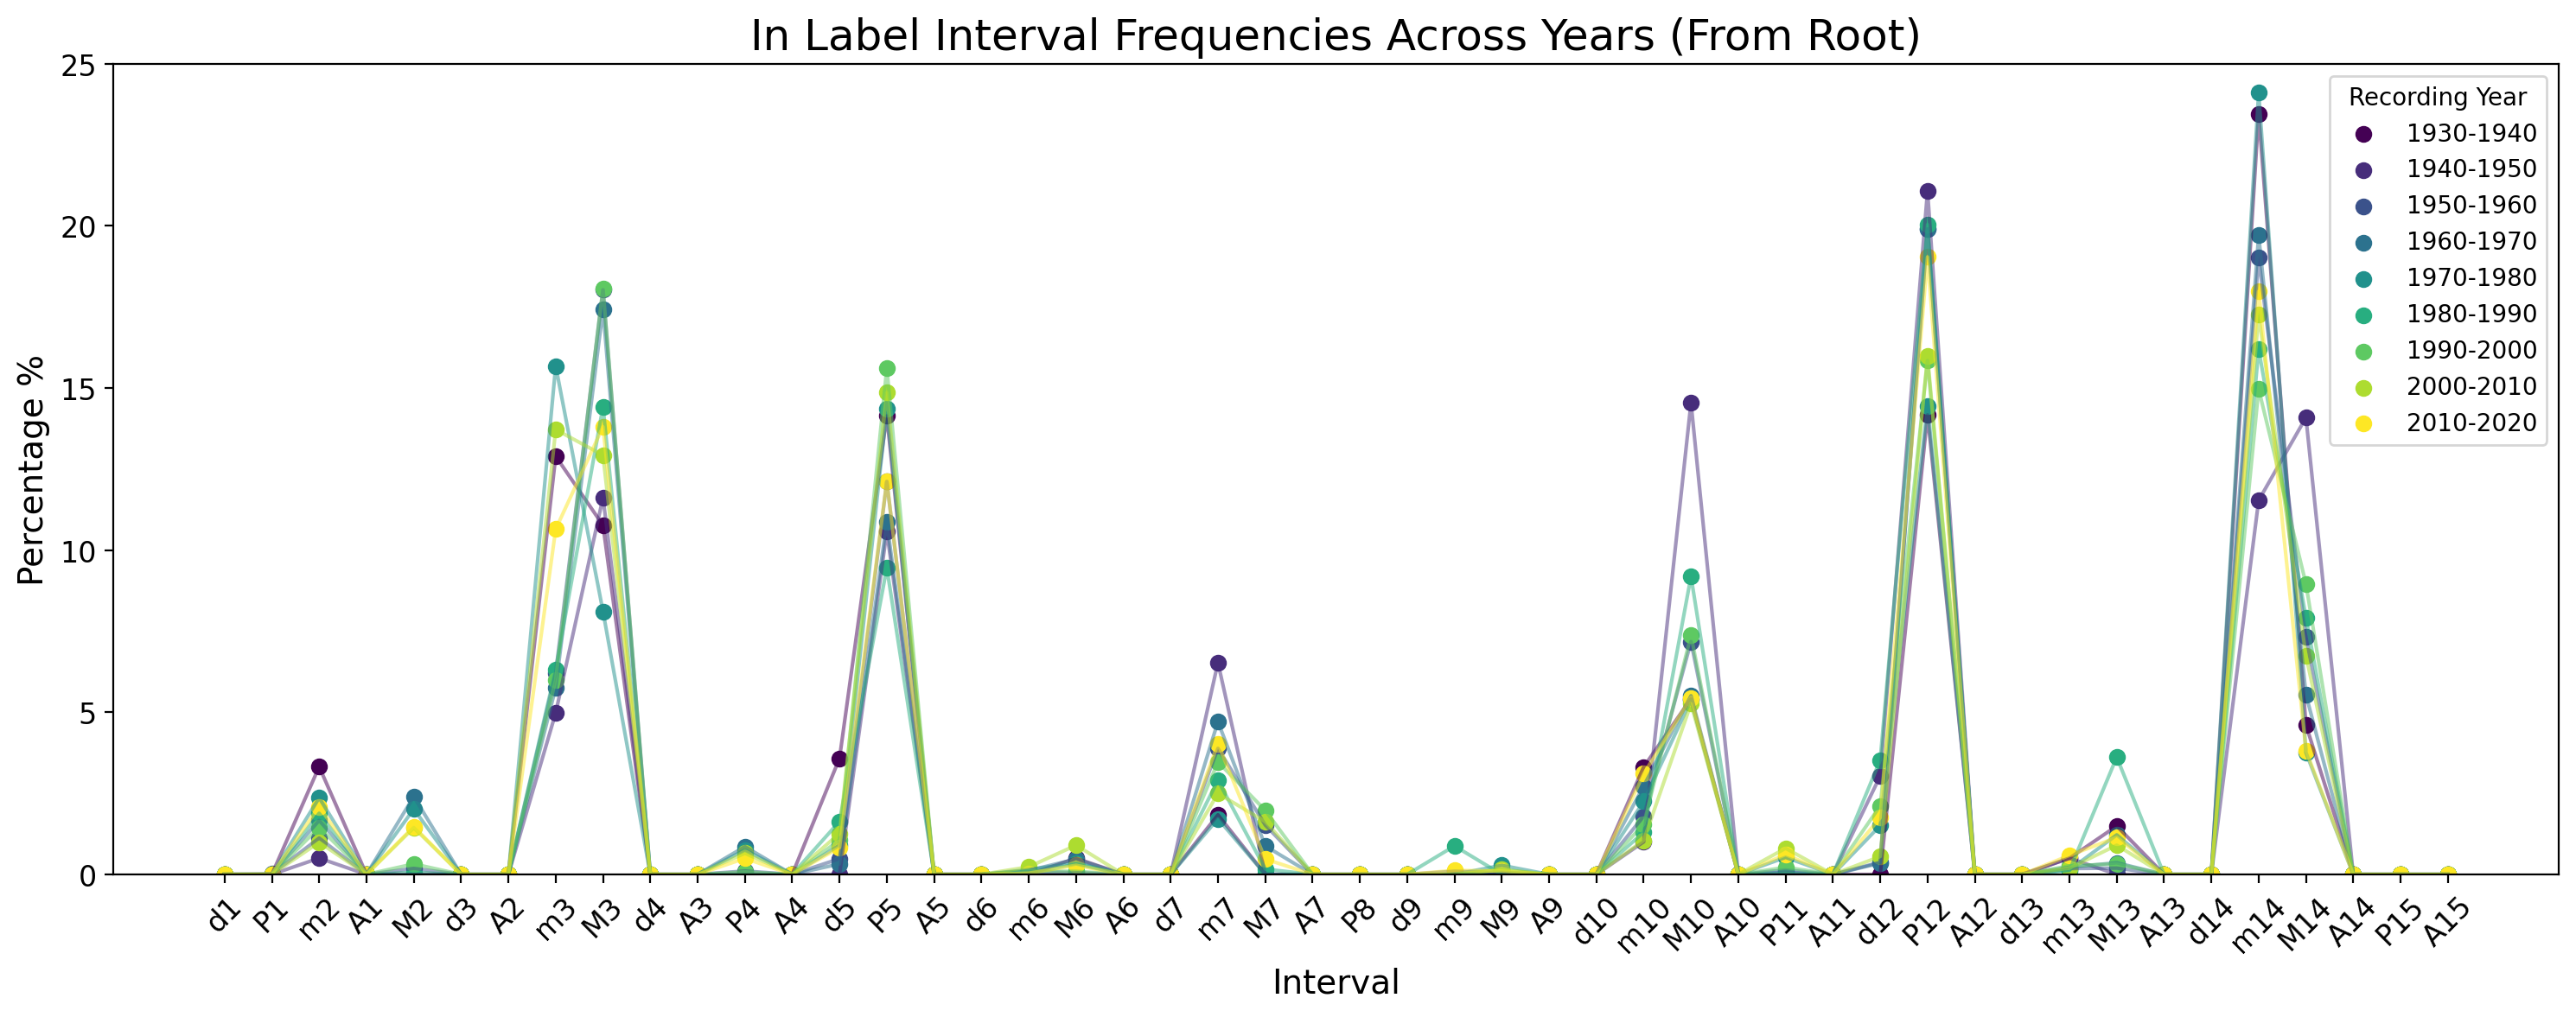

In [73]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_ILC_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data_ILC_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval from root'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.set_ylim(0, 25) 
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In Label Interval Frequencies Across Years (From Root)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_InLabel_From_Root")
plt.show()

## Heard Interval Analysis

### Example: Subset

In [13]:
metadata = g.load_metadata()
subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]

harmonies_subset = g.load_harmonies(subset)


error:name 'intervals_from_root' is not defined
error:name 'intervals_from_root' is not defined
error:name 'intervals_from_root' is not defined
error:name 'intervals_from_root' is not defined


ValueError: No objects to concatenate

In [168]:
harmonies_subset 

,artist,workTitle,fnames,rel_paths,recording_year,time,duration_qb,harmony,interval,semitones
0,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956.0,3.5,0.5,"[E5, F5]",[m2],[1]
1,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956.0,2.0,1.0,"[E5, F5]",[m2],[1]
2,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956.0,3.0,1.0,"[C#5, D5]",[m2],[1]
3,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956.0,1.5,0.5,"[G5, A-5, A5]","[m2, M2, m2]","[1, 2, 1]"
4,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956.0,2.0,1.0,"[C#5, D5]",[m2],[1]
...,...,...,...,...,...,...,...,...,...,...
92,Miles Davis,Four,Four - Miles Davis (Concert Key),by_Carles_Margarit,1956.0,3.0,0.5,"[E5, F5]",[m2],[1]
93,Miles Davis,Four,Four - Miles Davis (Concert Key),by_Carles_Margarit,1956.0,3.5,0.5,"[E5, A-5]",[M3],[4]
94,Miles Davis,Four,Four - Miles Davis (Concert Key),by_Carles_Margarit,1956.0,0.0,0.5,"[E5, A-5]",[M3],[4]
95,Miles Davis,Four,Four - Miles Davis (Concert Key),by_Carles_Margarit,1956.0,0.5,0.5,"[E5, F5]",[m2],[1]


In [169]:
identifier = ['artist', 'workTitle']
harmonies_subset = harmonies_subset.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(harmonies_subset, identifier)

In [170]:
#ia.plot_interval_distribution(data, identifier)

## By Artist

In [173]:
grouped_artists = subset_artist['artists'].value_counts()

subset_artists = grouped_artists.iloc[0:8].index
subset = metadata[metadata['artists'].isin(subset_artists)]

In [174]:
subset = g.load_harmonies(subset)
identifier = ['artist']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(subset, identifier)

/opt/anaconda3/lib/python3.12/site-packages/music21/musicxml/xmlToM21.py:2226: MusicXMLWarning: Warning: measure 57 in part Pianois overfull: 4.1640625 > 4.0,assuming 4.0 is correct.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/music21/musicxml/xmlToM21.py:2226: MusicXMLWarning: Warning: measure 71 in part Pianois overfull: 8.08203125 > 8.0,assuming 8.0 is correct.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/music21/musicxml/xmlToM21.py:2226: MusicXMLWarning: Warning: measure 79 in part Pianois overfull: 4.01171875 > 4.0,assuming 4.0 is correct.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/music21/musicxml/xmlToM21.py:5477: MusicXMLWarning: Could not import pedal: Error in getting PedalMark
  warnings.warn(f'Could not import {tag}: {excep}', MusicXMLWarning)
/opt/anaconda3/lib/python3.12/site-packages/music21/musicxml/xmlToM21.py:5477: MusicXMLWarning: Could not import pedal: Error in getting PedalMark
  warnings.warn(f'Could not import 

In [175]:
subset 

,artist,workTitle,fnames,rel_paths,recording_year,time,duration_qb,harmony,interval,semitones
0,Bill Evans,"[All The Things You Are, All The Things You Ar...","[All The Things You Are, All The Things You Ar...","[by_William_Hughes_(only_Bill_Evans), by_Willi...","[1963.0, 1963.0, 1963.0, 1963.0, 1963.0, 1963....","[2.5, 0.0, 4.0, 5.5, 0.0, 0.0, 2.5, 0.0, 0.0, ...","[1.5, 4.0, 1.5, 0.5, 4.0, 3.5, 1.5, 4.0, 1.0, ...","[[C#3, B3, E4, A#4, D#5, F#5], [C#3, B3, E4, A...","[[m7, m10, M13, M2, P4, P4, M7, M10, P12, d5, ...","[[10, 15, 21, 2, 5, 5, 11, 16, 19, 6, 11, 14, ..."
1,Bob Mintzer,"[12 Keys Blues, 12 Keys Blues, 12 Keys Blues, ...","[12 Keys Blues - Bob Mintzer, 12 Keys Blues - ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[2010.0, 2010.0, 2010.0, 2010.0, 2004.0, 2004....","[0.5, 2.0, 0.5, 0.0, 0.0, 0.0, 1.5, 3.5, 2.0, ...","[1.5, 1.0, 1.5, 1.0, 1.5, 1.5, 0.5, 0.5, 0.5, ...","[[F#5, G5], [C6, D-6], [A4, B-4], [A#5, B5], [...","[[m2], [m2], [m2], [m2], [m2], [m2], [m2], [P1...","[[1], [1], [1], [1], [1], [1], [1], [0, 2, 2],..."
2,Chet Baker,"[Autumn Leaves, Autumn Leaves, Autumn Leaves, ...","[Autumn Leaves - Chet Baker (Concert Key), Aut...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1974.0, 1974.0, 1974.0, 1974.0, 1987.0, 1987....","[0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 2.0, 0.0, 2.0, ...","[3.0, 1.0, 4.0, 3.0, 1.0, 0.5, 1.5, 1.5, 2.0, ...","[[B4, C5], [C#5, D5], [C#5, D5], [C#5, D5], [A...","[[m2], [m2], [m2], [m2], [m2], [m2], [m2], [m2...","[[1], [1], [1], [1], [1], [1], [1], [1], [1], ..."
3,Dexter Gordon,"[Blue Bossa, Blue Bossa, Blue Bossa, Blue Boss...","[Blue Bossa - Dexter Gordon, Blue Bossa - Dext...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1976.0, 1976.0, 1976.0, 1976.0, 1976.0, 1976....","[2.5, 2.0, 0.0, 2.0, 0.0, 3.0, 3.5, 3.0, 3.5, ...","[1.5, 1.5, 1.5, 1.5, 1.5, 0.5, 0.5, 1.0, 0.5, ...","[[B4, C5], [F#5, G5], [E5, F5], [F#5, G5], [E5...","[[m2], [m2], [m2], [m2], [m2], [M2], [m2], [m2...","[[1], [1], [1], [1], [1], [2], [1], [1], [1], ..."
4,Frank Zappa,"[A Little Green Rosetta, A Little Green Rosett...","[A Little Green Rosetta, A Little Green Rosett...","[by_Kristine_Kier_Jørgensen, by_Kristine_Kier_...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2.0, 1.0, 2.0, 3.0, 3.5, 0.0, 0.5, 1.0, 2.0, ...","[0.5, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5, ...","[[A2, C3, D3, E3], [D3, D4, F4, A4], [F4, A4, ...","[[m3, P4, P5, M2, M3, M2], [P8, m10, P12, m3, ...","[[3, 5, 7, 2, 4, 2], [12, 15, 19, 3, 7, 4], [4..."
5,Miles Davis,"[Bags’ Groove, Bags’ Groove, Bags’ Groove, Bag...","[Bags Groove - Miles Davis (Concert Key), Bags...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1957.0, 1957.0, 1957.0, 1957.0, 1957.0, 1957....","[3.0, 3.0, 2.0, 0.5, 0.0, 3.0, 0.5, 0.0, 3.0, ...","[0.5, 0.5, 1.5, 1.0, 1.5, 1.0, 1.0, 0.5, 0.5, ...","[[E5, F5], [G5, A-5], [G#5, A5], [G#5, A5], [G...","[[m2], [m2], [m2], [m2], [m2], [m2], [m2], [m2...","[[1], [1], [1], [1], [1], [1], [1], [1], [1], ..."
6,Paul Desmond,"[All The Things You Are, All The Things You Ar...",[All The Things You Are - Paul Desmond (Concer...,"[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1962.0, 1962.0, 1962.0, 1962.0, 1962.0, 1962....","[2.0, 0.0, 2.0, 0.0, 2.0, 0.0, 2.0, 0.0, 2.0, ...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[A-4, F5], [D-5, F5], [B-4, D-5], [G4, B-4], ...","[[M6], [M3], [m3], [m3], [m6], [m3], [M3], [m3...","[[9], [4], [3], [3], [8], [3], [4], [3], [8], ..."
7,Yohan Kim,"[Amazing Grace\nDedicated to Yohan Kim\n, Amaz...","[Amazing Grace - Yohan Kim, Amazing Grace - Yo...","[by_Cornelius_Tsen, by_Cornelius_Tsen, by_Corn...","[2017.0, 2017.0, 2017.0, 2017.0, 2017.0, 2017....","[0.0, 0.5, 0.0, 0.25, 0.5, 0.75, 0.83203125, 0...","[0.5, 0.5, 0.25, 0.25, 0.25, 0.08203125, 0.082...","[[E-2, B-2, F3, G3, B-3, C4, E-4], [F3, G3, B-...","[[P5, M9, M10, P12, M13, P1, P5, M6, P8, M9, P...","[[7, 14, 16, 19, 21, 0, 7, 9, 12, 14, 17, 2, 5..."


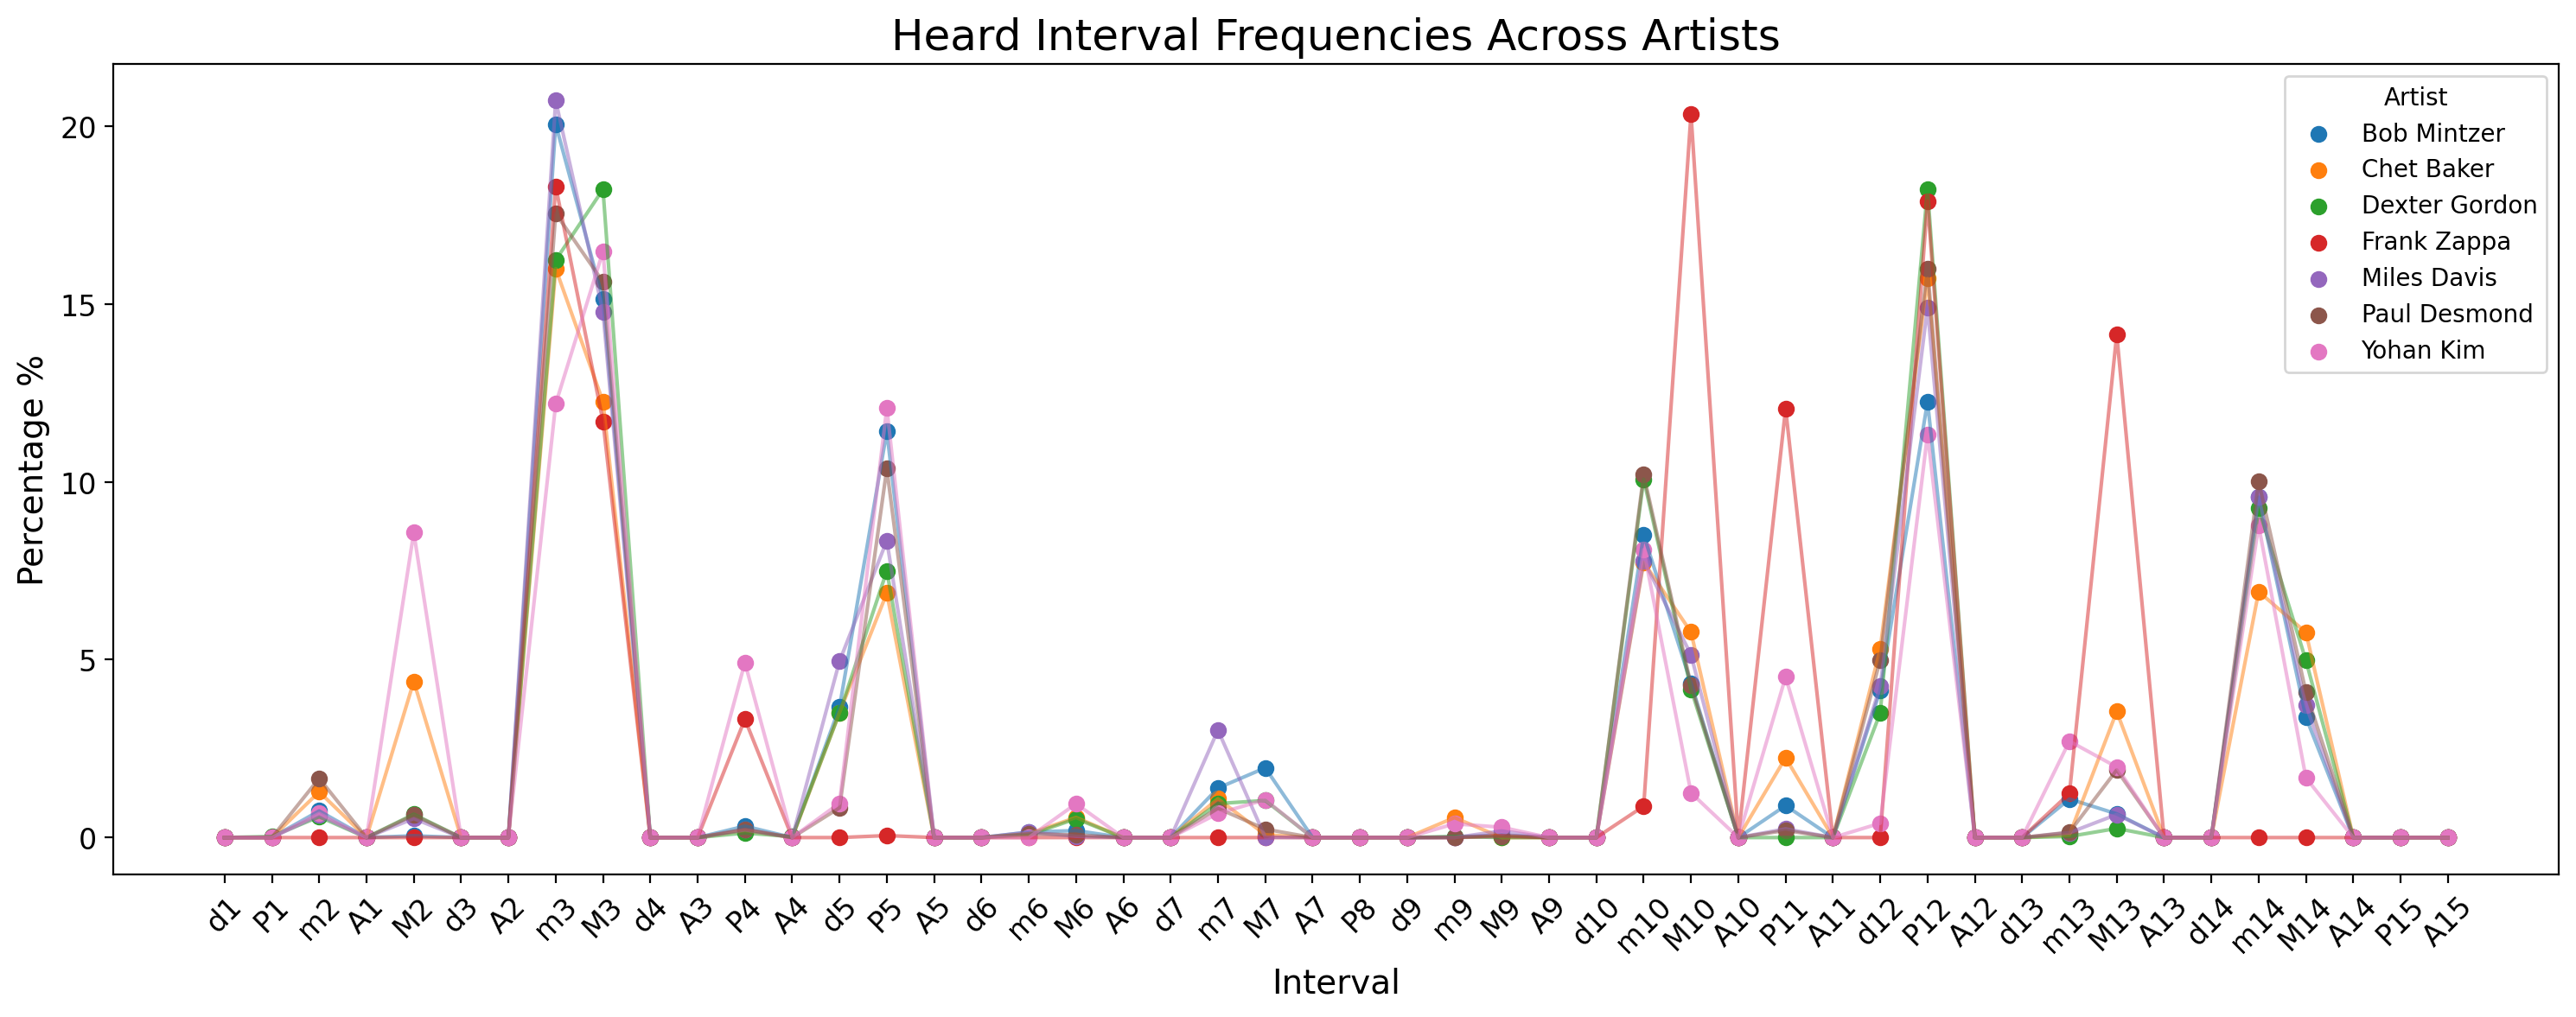

In [211]:


baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['tab10']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i))
    
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)

ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Artists', fontsize=18)
ax.legend(title='Artist')


plt.tight_layout()
plt.savefig(f"../Results/Artist_Interval_Heard")
plt.show()

## By Year

In [19]:
heard_harmonies = g.load_harmonies(subset_year)

error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Steve_Aho/Deep Space _ Solar.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Steve_Aho/Deep Space _ Solar with rounded off Tempo Map.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Timothy_Gondola/42nd Street/42nd Street.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Timothy_Gondola/Armando's Rhumba/Armando's Rhumba.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Timothy_Gondola/As For Us/As For Us.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Timothy_Gondola/At The Cross/At The Cross.xml
error:Cannot find file in /Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Timothy_Gondola/Awakeni

In [60]:
heard_harmonies = heard_harmonies[heard_harmonies['recording_year'].notna()]
heard_harmonies['year_bin'] = pd.cut(heard_harmonies['recording_year'], bins=bins, labels=bin_labels, right=False)
heard_harmonies = heard_harmonies[(heard_harmonies['year_bin'] != '1930-1940')& (heard_harmonies['year_bin'] != '1940-1950')]
heard_harmonies['year_bin'] = heard_harmonies['year_bin'].cat.remove_unused_categories()
identifier = ['year_bin']
heard_harmonies_grouped = heard_harmonies.groupby(identifier, as_index=False).agg(list)
data_heard_year = ia.create_data(heard_harmonies_grouped, identifier)

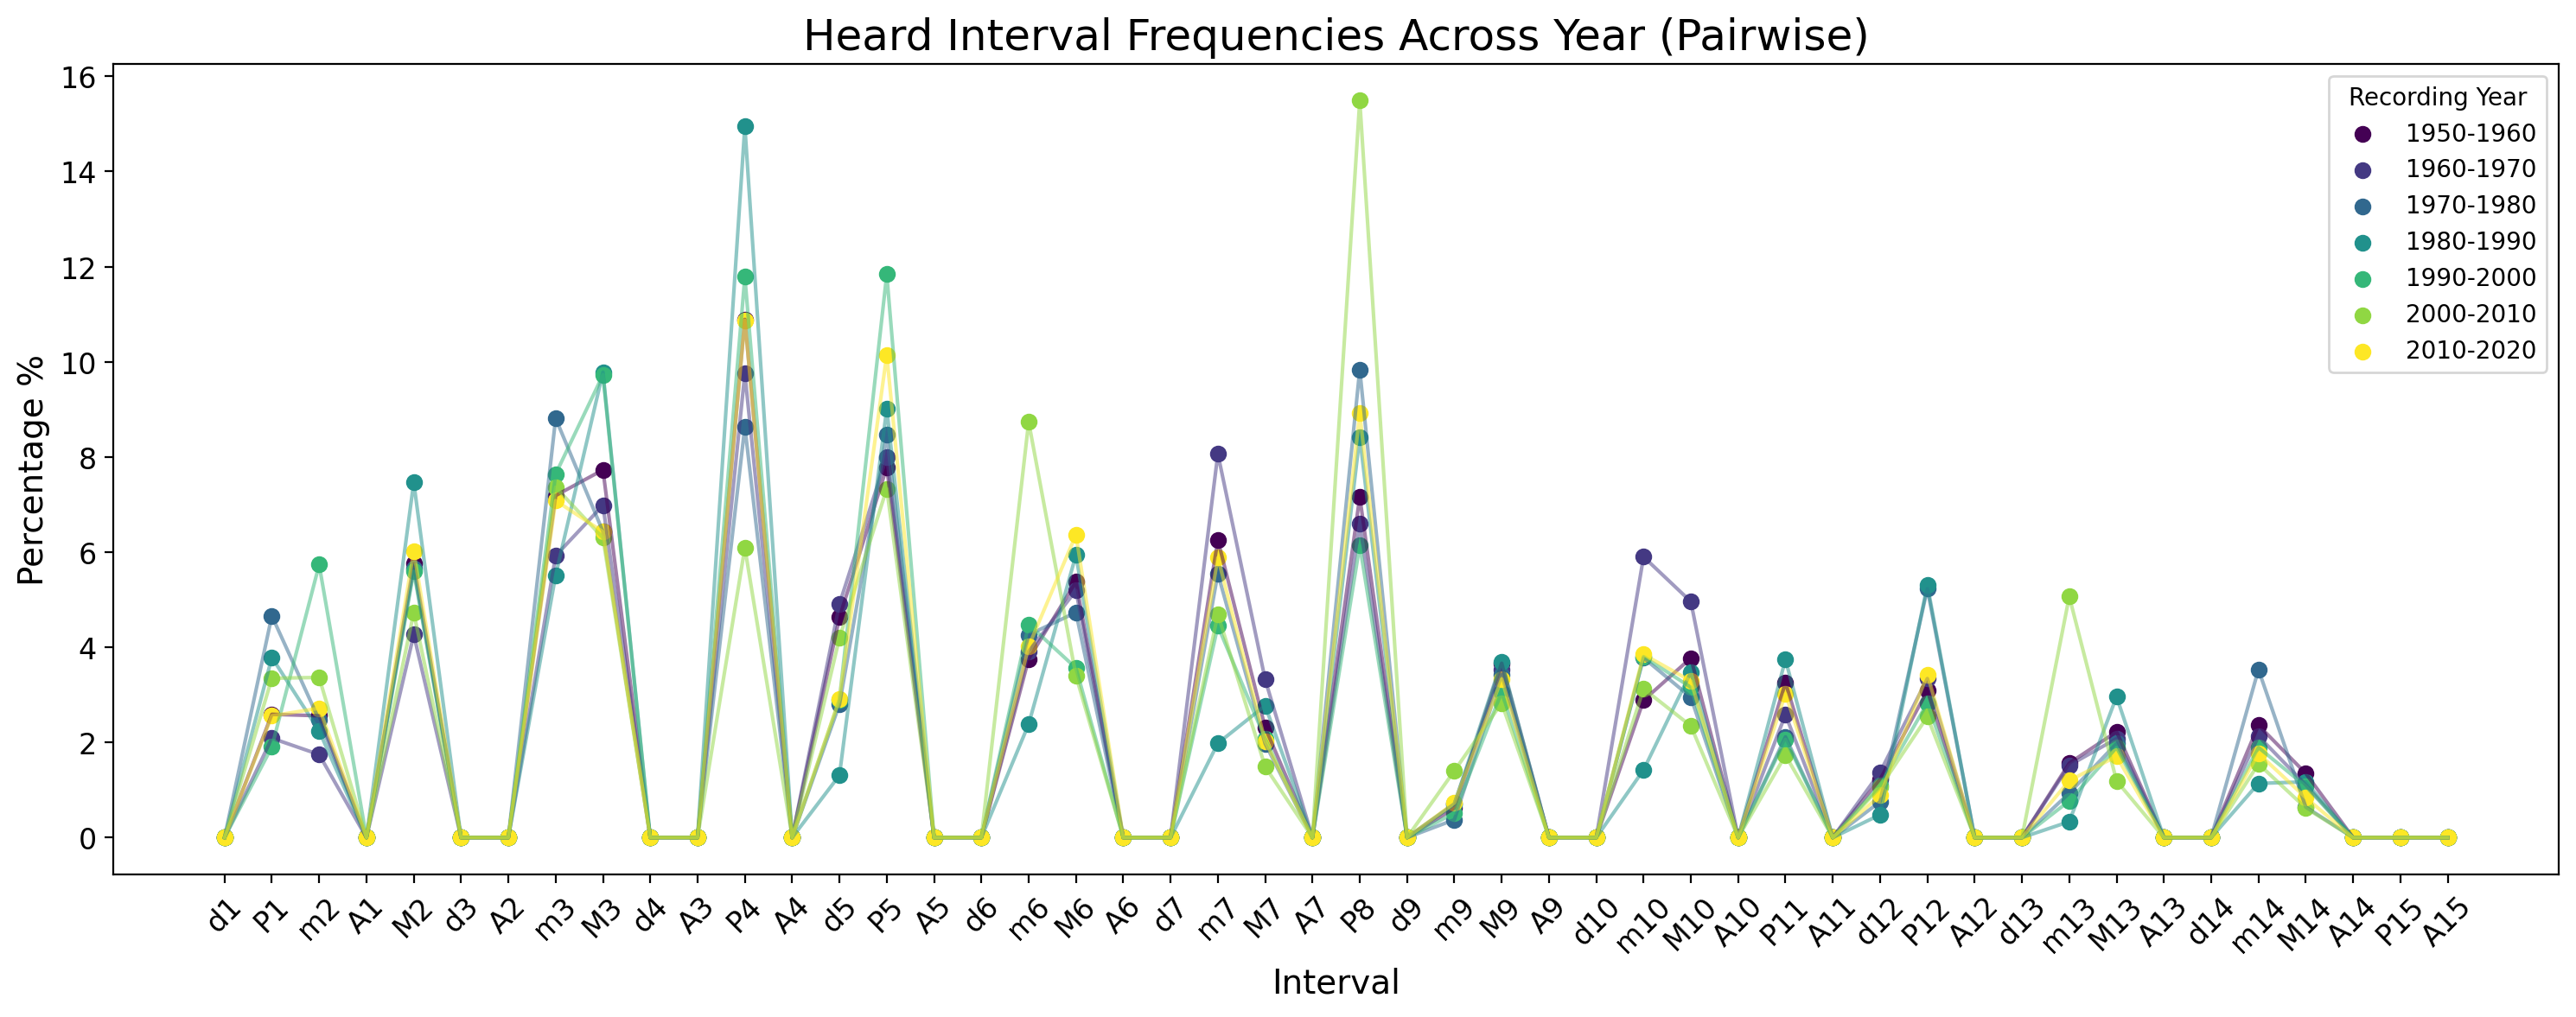

In [66]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_heard_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data_heard_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Year (Pairwise)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_Heard_Cut")
plt.show()


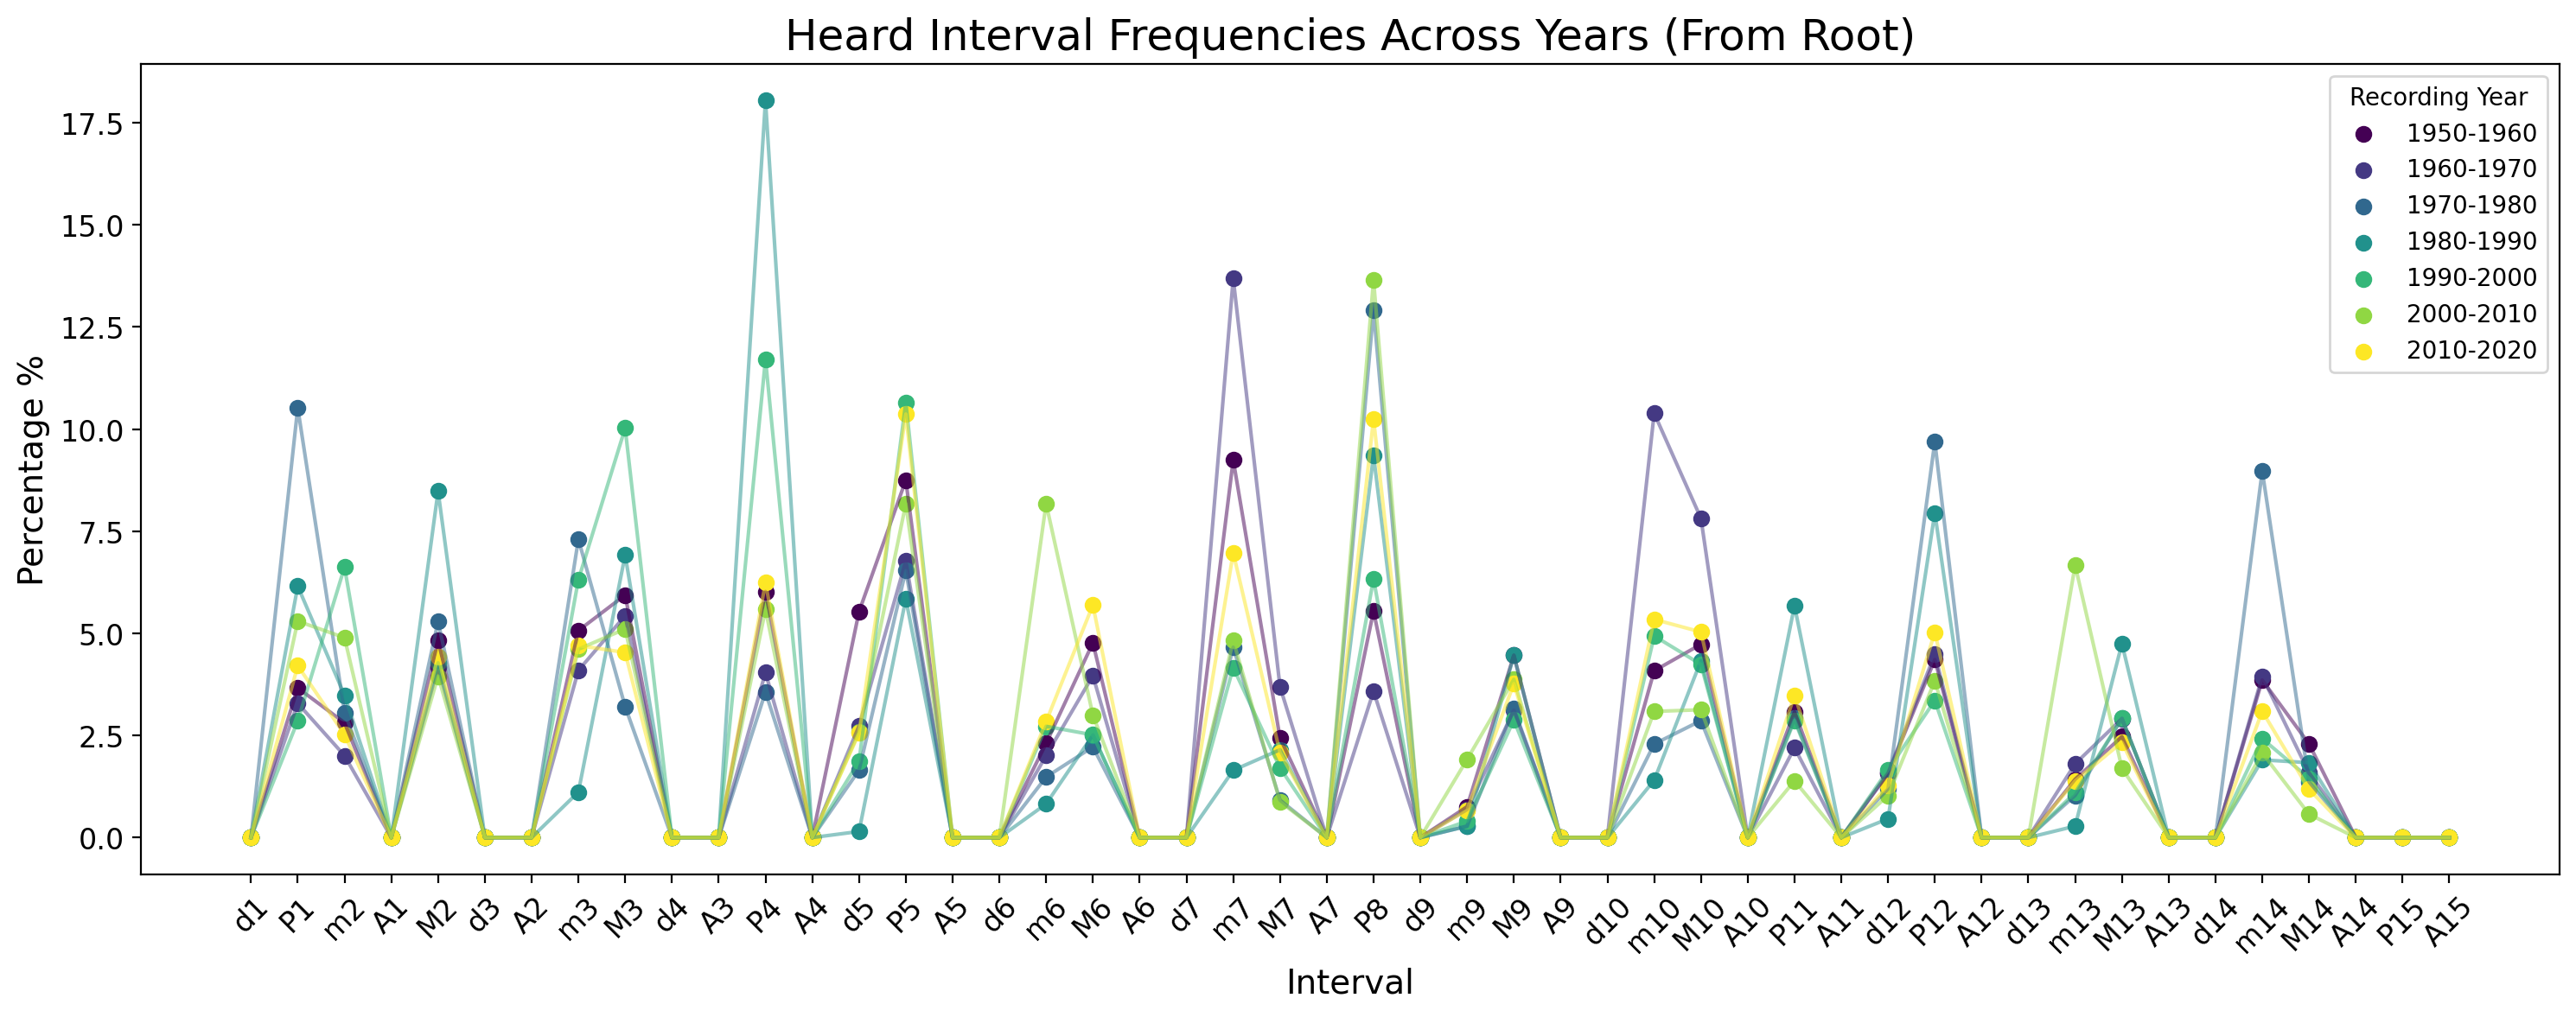

In [68]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_heard_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data_heard_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval from root'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Years (From Root)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_Heard_From_Root")
plt.show()